## Constructing a Synthetic NMR Echo Data using Deep Learning

### By Arick Jurdan, Lorena Mamede

### Núcleo de Computação Eletrônica/Instituto Tércio Pacitti de Aplicações e Pesquisas Computacionais (NCE/UFRJ)

### Federal University of Rio de Janeiro (UFRJ)

****

**Summary:** This pipeline generates synthetic raw Nuclear Magnetic Resonance (NMR) echo train signals from volumetric well-logging data (such as MPHI, MBVI, and PHIX).The objective is to reconstruct the magnetization decay $M(t)$ so that it rigorously reflects the physics of the rock's irreducible water saturation, enabling the creation of realistic and controlled datasets for the training and validation of predictive algorithms.


**Approach:**  The methodology is based on the forward modeling of the NMR signal, linking macroscopic log measurements to the quantum mechanics of proton decay, structured in the following steps:
1. volumes derived from logging are used to define pore filling. The MBVI variable dictates the exact area under the distribution curve associated with micropores (short relaxation times). Free fluid (MPHI minus MBVI) dictates the area of ​​the curve associated with macropores (long relaxation times).
2. Statistical Pore Modeling: The pore space is synthesized by imposing continuous log-normal distributions in the transverse relaxation time ($T_2$) domain, parameterized to reflect the natural heterogeneity of the rock matrix.
3. The ideal magnetization decay is computed by applying a multi-exponential decay matrix to the generated $T_2$ distributions.


**Assumptions:**

1. Pore sizes follow a log-normal distribution (consult classical petrophysics literature to determine the appropriate mean and standard deviation parameters for simulating realistic pore distributions in the lithology of interest).

2. The samples represent a system containing only a single fluid within the pores (water), thereby eliminating complex oil/gas relaxation effects and deviations caused by.

The data originate from one reservoirs with similar properties, ensuring that the log-normal model hyperparameters can be generalized and consistently applied across the entire dataset.

**References:**

[1] [Open-Source-Petrophysics](https://github.com/Philliec459/Open-Source-Petrophysics) by Craig Phillips ->
A comprehensive open-source repository for Petrophysics, providing tools, scripts, and resources for subsurface data analysis.

[2] [synthetic_well-log_polynomial_regression](https://github.com/abhishekdbihani/synthetic_well-log_polynomial_regression) by Abhishek Bihani -> 
  Machine learning project for constructing missing well logs (e.g. NMR) from other available logs. 

[3] [Gulf of Mexico Gas Hydrate Dataset](10.1016/j.marpetgeo.2011.08.003) Collett, T. S., Lee, M. W., Zyrianova, M. V., Mrozewski, S. a., Guerin, G., Cook, A. E., and Goldberg, D. S. (2012). Gulf of Mexico Gas Hydrate Joint Industry Project Leg II logging- while-drilling data acquisition and analysis. Marine and Petroleum Geology

### Inital analysis

First all the packages required for the workflow are imported

In [1]:
# pip install -r requirements.txt

%matplotlib inline

import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import pandas.plotting as pd_plot           
import scipy
from scipy import linalg               
from scipy import stats                  
import seaborn as sns 

### EDA: 

In [27]:
#Summary statistics of processed data
df = pd.read_csv('data/GulfCoast.csv')
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,575.0,287.000000,166.132477,0.000000,143.500000,287.000000,430.500000,574.000000
PHIX,575.0,0.374149,0.022407,0.305548,0.357231,0.373023,0.391822,0.428870
MBVI,575.0,0.159465,0.064619,0.041610,0.108345,0.150895,0.201820,0.327490
MPHI,575.0,0.311427,0.062643,0.150480,0.289735,0.330530,0.353580,0.473960
Swirr_PHIX,575.0,0.434547,0.194175,0.115263,0.275361,0.410195,0.560260,0.967319


In [56]:
#Summary statistics of processed data
df = pd.read_csv('data/GulfCoast.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  575 non-null    int64  
 1   PHIX        575 non-null    float64
 2   MBVI        575 non-null    float64
 3   MPHI        575 non-null    float64
 4   Swirr_PHIX  575 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 22.6 KB


In [10]:
# Decay function (discrete case) [1]
def func(x, p1, p2, p3, p4, p5, p6, p7, p8):
    return (p1 * np.exp(-x / 4) +
            p2 * np.exp(-x / 8) +
            p3 * np.exp(-x / 16) +
            p4 * np.exp(-x / 32) +
            p5 * np.exp(-x / 64) +
            p6 * np.exp(-x / 128) +
            p7 * np.exp(-x / 256) +
            p8 * np.exp(-x / 512))

In [ ]:
### Test using the discrete case

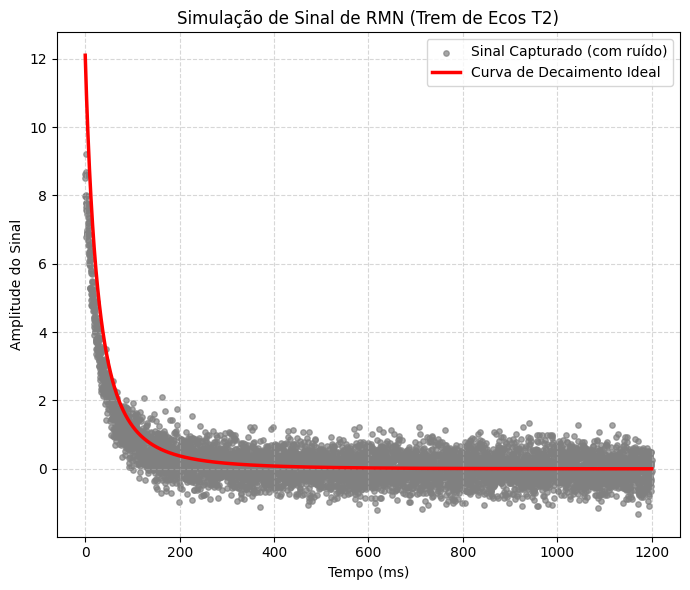

In [39]:
num_echoes = 6000
TE = 0.2  # (Echo spacing)
xdata = np.arange(num_echoes) * TE
phase_angle = np.pi / 4  

# creating sings with values 1 to 8
# Exemplo: um solo com muita umidade nos poros médios (P3, P4, P5)
P1, P2, P3, P4, P5, P6, P7, P8 = 0.1, 0.5, 3.0, 5.0, 2.5, 0.8, 0.2, 0.0
y_clean = func(xdata, P1, P2, P3, P4, P5, P6, P7, P8)

# addinjf noise in both channels (canais Real e Imaginário)
noise_level = 0.4
noise_train = np.random.normal(0, noise_level, size=num_echoes * 2)

noise_real = noise_train[:num_echoes]
noise_imag = noise_train[num_echoes:]
y_real_noisy = (y_clean * np.cos(phase_angle)) + noise_real
y_imag_noisy = (y_clean * np.sin(phase_angle)) + noise_imag

# total
y_magnitude = y_real_noisy + 1j * y_imag_noisy

# plot
plt.figure(figsize=(7, 6))
plt.scatter(xdata, y_magnitude, color='gray', alpha=0.7, label='Sinal Capturado (com ruído)', s=15)
plt.plot(xdata, y_clean, color='red', linewidth=2.5, label='Curva de Decaimento Ideal')
plt.title('Simulação de Sinal de RMN (Trem de Ecos T2)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude do Sinal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Creating a log normal distribution of T2 to moddeling decay

In [72]:
def log_normal_t2(T2, mu_t2, sigma, volume_fraction):
    """
    Gera uma distribuição Gaussiana no espaço logarítmico de T2.
    mu_t2: Centro geométrico em ms
    sigma: Largura da distribuição
    volume_fraction: Fração da porosidade ocupada
    """
    # Usamos base 10 para modelagem geofísica padrão
    log_T2 = np.log10(T2)
    log_mu = np.log10(mu_t2)
    curve = np.exp(-((log_T2 - log_mu)**2) / (2 * sigma**2))
    
    # Normalizamos a área para bater com a fração de volume desejada
    area = np.trapezoid(curve, log_T2)
    return (curve / area) * volume_fraction * porosity

C:\Users\aryck\AppData\Local\Temp\ipykernel_22596\1581861400.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_irr = np.trapz(curve_irr, np.log10(T2_bins))


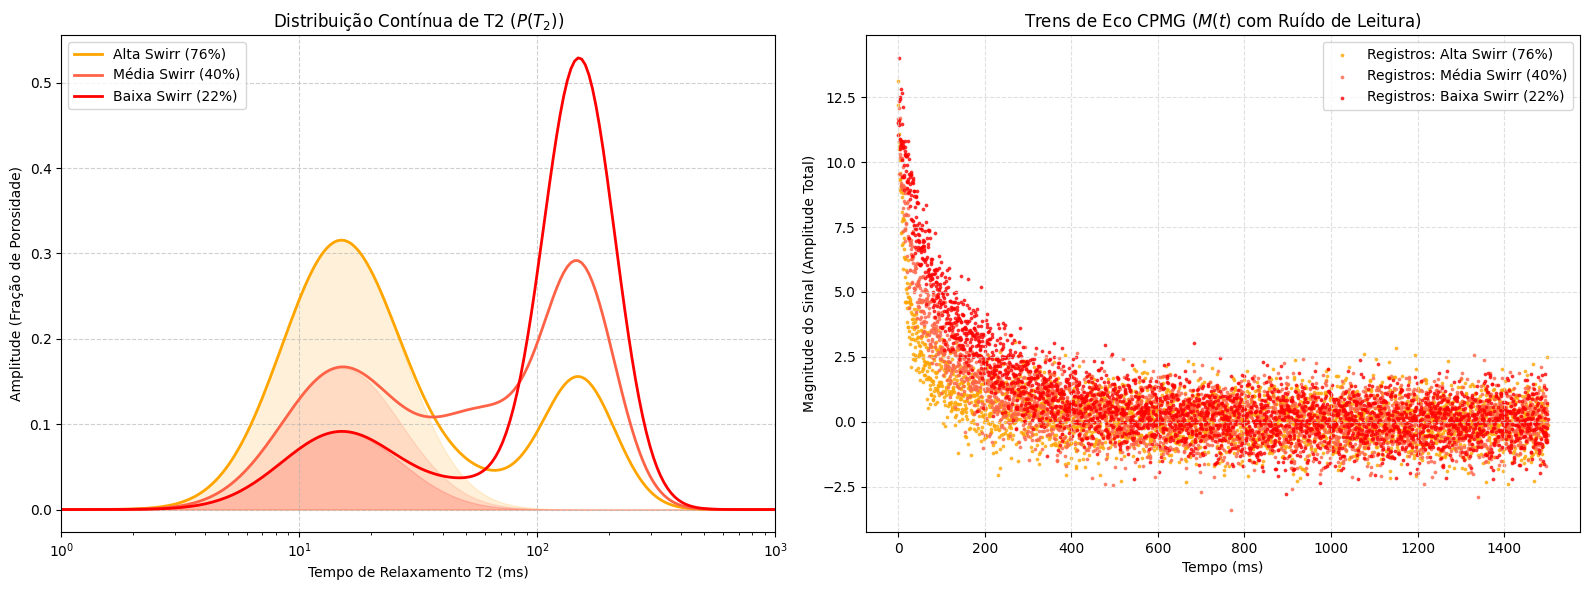

In [73]:
# Parâmetros Físicos e da Aquisição (de acordo com a literatura)
TE = 0.5  # Espaçamento (500 μs)
num_echoes = 3000
t = np.arange(1, num_echoes + 1) * TE
porosity = 0.26
noise_level = 0.8

# Amostragem Adequada (200 bins espaçados logaritmicamente entre 1 ms e 1000 ms)
num_bins = 200
T2_bins = np.logspace(0, 3, num_bins)

scenarios = [
    {"name": "Alta Swirr (76%)", "w_irr": 0.76, "w_free1": 0.05, "w_free2_oil": 0.22},
    {"name": "Média Swirr (40%)", "w_irr": 0.40, "w_free1": 0.20, "w_free2_oil": 0.40},
    {"name": "Baixa Swirr (22%)", "w_irr": 0.22, "w_free1": 0.05, "w_free2_oil": 0.76}
]

# Configurando o Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['orange', 'tomato', 'red']

for idx, sc in enumerate(scenarios):
    # GERANDO AS 3 CURVAS CONTÍNUAS
    curve_irr = log_normal_t2(T2_bins, mu_t2=15, sigma=0.25, volume_fraction=sc["w_irr"])
    curve_free1 = log_normal_t2(T2_bins, mu_t2=60, sigma=0.2, volume_fraction=sc["w_free1"])
    curve_free2 = log_normal_t2(T2_bins, mu_t2=150, sigma=0.15, volume_fraction=sc["w_free2_oil"])
    
    P_T2 = curve_irr + curve_free1 + curve_free2
    
    # ARMAZENANDO O VALOR DA SATURAÇÃO IRREDUTÍVEL
    area_irr = np.trapz(curve_irr, np.log10(T2_bins))
    swirr_armazenado = area_irr / porosity
    
    # GERANDO O DECAIMENTO M(t)
    Matriz_Exp = np.exp(-t[:, None] / T2_bins[None, :])
    decay_clean = np.dot(Matriz_Exp, P_T2)
    
    # Ruído
    noise_train = np.random.normal(0, noise_level, size=num_echoes * 2)
    y_real = (decay_clean * np.cos(np.pi / 4)) + noise_train[:num_echoes]
    y_imag = (decay_clean * np.sin(np.pi / 4)) + noise_train[num_echoes:]
    M_noisy = y_real + 1j * y_imag
    
    # Plotando Distribuição T2 (Sem alterações)
    ax1.plot(T2_bins, P_T2, label=f'{sc["name"]}', color=colors[idx], linewidth=2)
    ax1.fill_between(T2_bins, 0, curve_irr, color=colors[idx], alpha=0.15)
    
    # MODIFICAÇÃO: Plotando Decaimento com pontos (scatter) em vez de linha
    M_magnitude = y_real
    
    ax2.scatter(t, M_magnitude, color=colors[idx], alpha=0.7, s=3,
                label=f'Registros: {sc["name"]}')
    
    # Linha fina opcional apenas para guiar os olhos sobre a curva ideal por baixo do ruído
    # ax2.plot(t, decay_clean, color=colors[idx], linewidth=1.5, alpha=0.8)

# Formatando o Gráfico 1
ax1.set_xscale('log')
ax1.set_title('Distribuição Contínua de T2 ($P(T_2)$)', fontsize=12)
ax1.set_xlabel('Tempo de Relaxamento T2 (ms)')
ax1.set_ylabel('Amplitude (Fração de Porosidade)')
ax1.set_xlim(1, 1000)
ax2.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Formatando o Gráfico 2
ax2.set_title('Trens de Eco CPMG ($M(t)$ com Ruído de Leitura)', fontsize=12)
ax2.set_xlabel('Tempo (ms)')
ax2.set_ylabel('Magnitude do Sinal (Amplitude Total)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()
ax2.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)
plt.tight_layout()
plt.show()

### MODIFICAÇÃO 2: Simulando as linhas no caso real: Cada dicionário representa uma profundidade do seu poço

In [42]:
dados_csv = [
    {"Profundidade": 1000, "PHIX": 0.28, "MPHI": 0.29, "MBVI": 0.22}, # Alta Swirr
    {"Profundidade": 1010, "PHIX": 0.25, "MPHI": 0.26, "MBVI": 0.10}, # Média Swirr
    {"Profundidade": 1020, "PHIX": 0.24, "MPHI": 0.25, "MBVI": 0.03}  # Baixa Swirr
]

# função agora recebe o "volume absoluto" diretamente (ex: MBVI) 
# em vez de fração * porosidade global.
def log_normal_t2(T2, mu_t2, sigma, absolute_volume):
    log_T2 = np.log10(T2)
    log_mu = np.log10(mu_t2)
    curve = np.exp(-((log_T2 - log_mu)**2) / (2 * sigma**2))
    area = np.trapz(curve, log_T2)
    return (curve / area) * absolute_volume

C:\Users\aryck\AppData\Local\Temp\ipykernel_22596\2691080888.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(curve, log_T2)


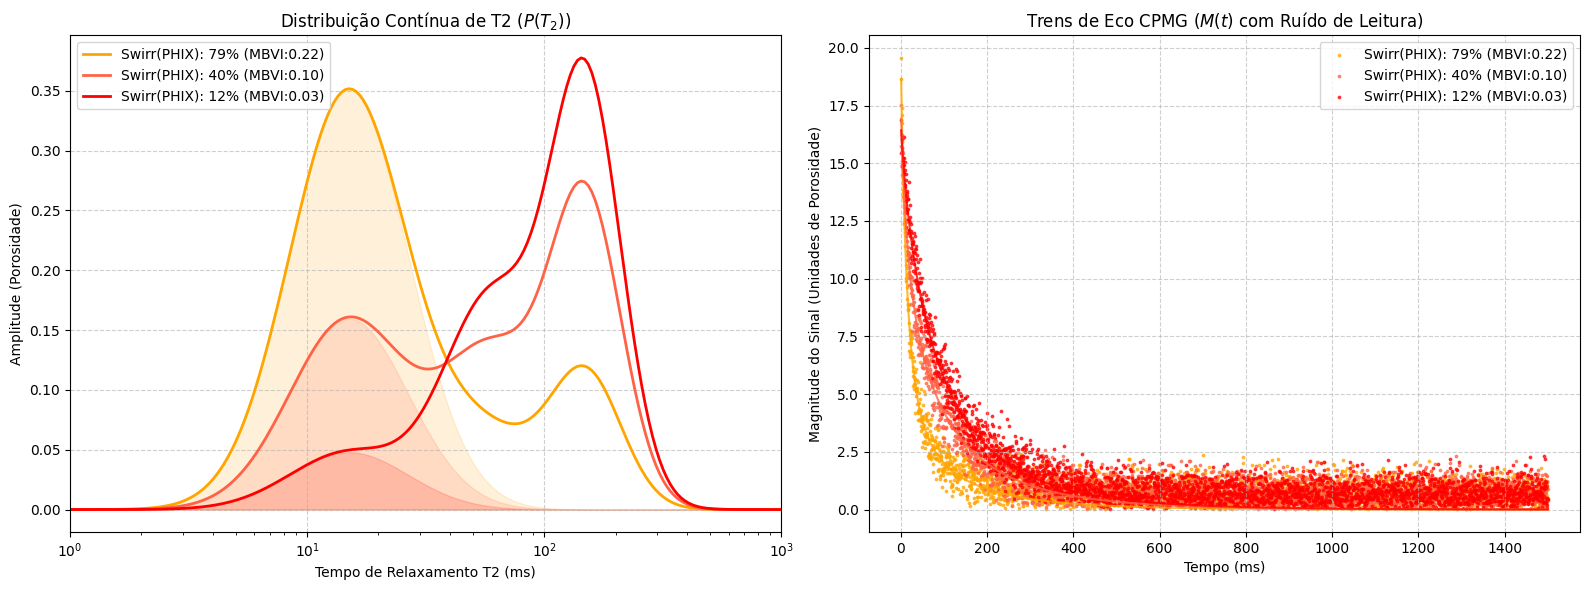

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['orange', 'tomato', 'red']

for idx, row in enumerate(dados_csv):
    
    Swirr_PHIX = row["MBVI"] / row["PHIX"]
    
    vol_irr = row["MBVI"]                  # Volume preso (pico rápido)
    vol_free = row["MPHI"] - row["MBVI"]   # Volume livre (pico lento)
    
    # Dividindo o fluido livre em dois picos para manter a complexidade do seu código original (opcional)
    vol_free1 = vol_free * 0.4
    vol_free2 = vol_free * 0.6
    
    # GERANDO AS CURVAS
    curve_irr = log_normal_t2(T2_bins, mu_t2=15, sigma=0.25, absolute_volume=vol_irr)
    curve_free1 = log_normal_t2(T2_bins, mu_t2=60, sigma=0.2, absolute_volume=vol_free1)
    curve_free2 = log_normal_t2(T2_bins, mu_t2=150, sigma=0.15, absolute_volume=vol_free2)
    
    P_T2 = curve_irr + curve_free1 + curve_free2
    
    # GERANDO O DECAIMENTO M(t)
    Matriz_Exp = np.exp(-t[:, None] / T2_bins[None, :])
    decay_clean = np.dot(Matriz_Exp, P_T2)
    
    # Ruído de leitura sintético
    noise_train = np.random.normal(0, noise_level, size=num_echoes * 2)
    y_real = (decay_clean * np.cos(np.pi / 4)) + noise_train[:num_echoes]
    y_imag = (decay_clean * np.sin(np.pi / 4)) + noise_train[num_echoes:]
    M_noisy = np.sqrt(y_real**2 + y_imag**2)
    
    # Nome para a legenda baseado nos dados reais
    label_name = f'Swirr(PHIX): {Swirr_PHIX*100:.0f}% (MBVI:{vol_irr:.2f})'
    
    # PLOTANDO
    ax1.plot(T2_bins, P_T2, label=label_name, color=colors[idx], linewidth=2)
    ax1.fill_between(T2_bins, 0, curve_irr, color=colors[idx], alpha=0.15)
    
    ax2.scatter(t, M_noisy, color=colors[idx], alpha=0.7, s=3, label=label_name)
    ax2.plot(t, decay_clean, color=colors[idx], linewidth=1.5, alpha=0.8)

ax1.set_xscale('log')
ax1.set_title('Distribuição Contínua de T2 ($P(T_2)$)', fontsize=12)
ax1.set_xlabel('Tempo de Relaxamento T2 (ms)')
ax1.set_ylabel('Amplitude (Porosidade)')
ax1.set_xlim(1, 1000)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.set_title('Trens de Eco CPMG ($M(t)$ com Ruído de Leitura)', fontsize=12)
ax2.set_xlabel('Tempo (ms)')
ax2.set_ylabel('Magnitude do Sinal (Unidades de Porosidade)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()
plt.tight_layout()
plt.show()

C:\Users\aryck\AppData\Local\Temp\ipykernel_22596\1681210843.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(curve, log_T2)


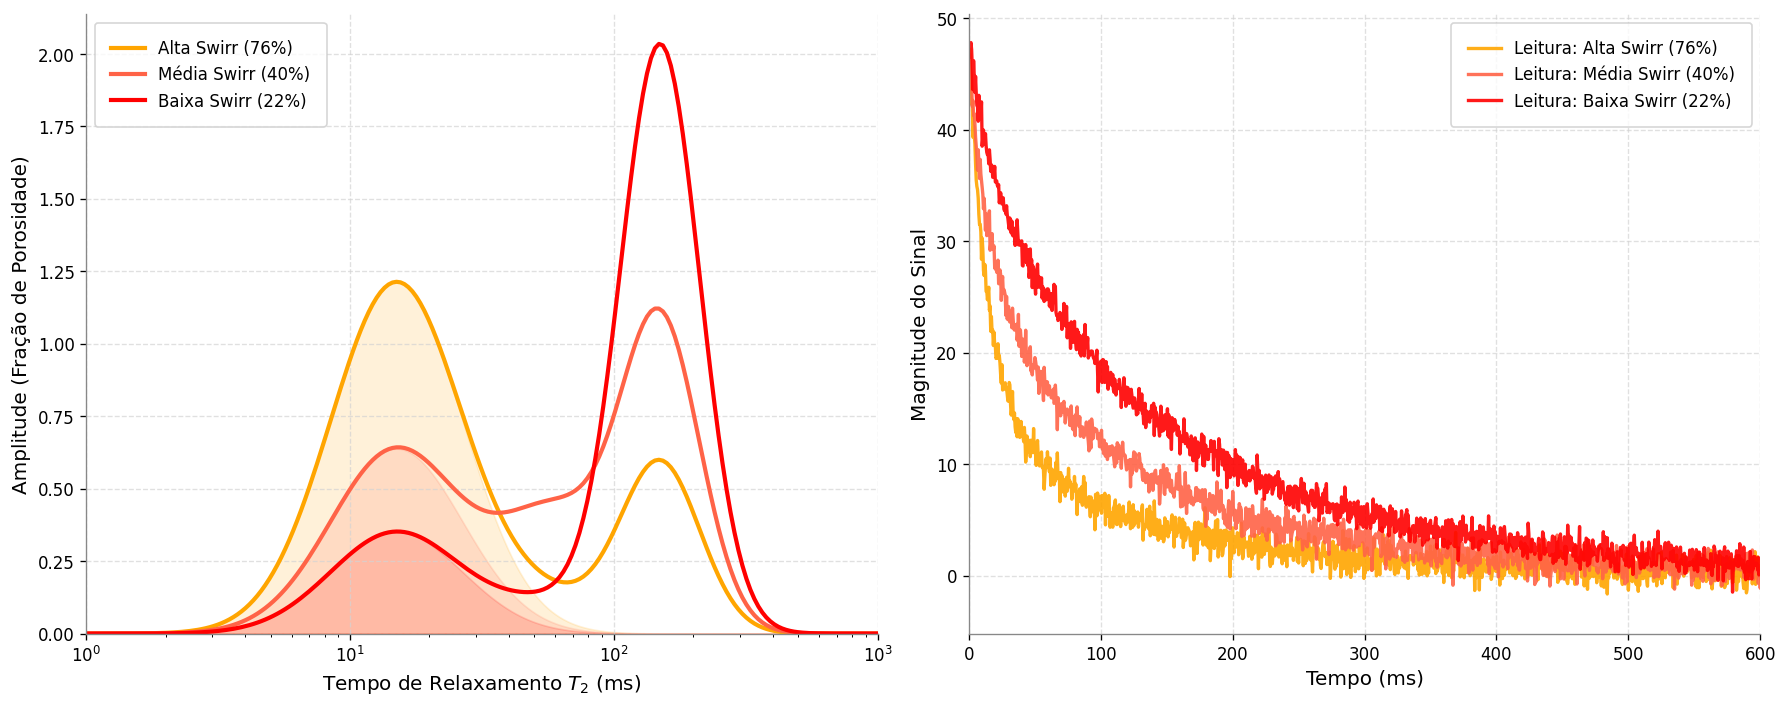

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Função de geração da curva
def log_normal_t2(T2, mu_t2, sigma, volume_fraction):
    log_T2 = np.log10(T2)
    log_mu = np.log10(mu_t2)
    curve = np.exp(-((log_T2 - log_mu)**2) / (2 * sigma**2))
    area = np.trapz(curve, log_T2)
    return (curve / area) * volume_fraction if area > 0 else np.zeros_like(T2)

# --- PARÂMETROS FÍSICOS E DA AQUISIÇÃO ---
TE = 0.5  # Espaçamento (500 μs)
num_echoes = 3000
t = np.arange(1, num_echoes + 1) * TE
porosity = 0.26
noise_level = 0.8

num_bins = 200
T2_bins = np.logspace(0, 3, num_bins)

scenarios = [
    {"name": "Alta Swirr (76%)", "w_irr": 0.76, "w_free1": 0.05, "w_free2_oil": 0.22},
    {"name": "Média Swirr (40%)", "w_irr": 0.40, "w_free1": 0.20, "w_free2_oil": 0.40},
    {"name": "Baixa Swirr (22%)", "w_irr": 0.22, "w_free1": 0.05, "w_free2_oil": 0.76}
]

# --- CONFIGURANDO O PLOT (ESTILO CIENTÍFICO CLEAN) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
fig.patch.set_facecolor('white') # Fundo branco limpo

# Suas cores originais
colors = ['orange', 'tomato', 'red']

# Calculando a matriz exponencial fora do loop (Otimização)
Matriz_Exp = np.exp(-t[:, None] / T2_bins[None, :])

for idx, sc in enumerate(scenarios):
    # 1. GERANDO AS 3 CURVAS CONTÍNUAS
    curve_irr = log_normal_t2(T2_bins, mu_t2=15, sigma=0.25, volume_fraction=sc["w_irr"])
    curve_free1 = log_normal_t2(T2_bins, mu_t2=60, sigma=0.2, volume_fraction=sc["w_free1"])
    curve_free2 = log_normal_t2(T2_bins, mu_t2=150, sigma=0.15, volume_fraction=sc["w_free2_oil"])
    
    P_T2 = curve_irr + curve_free1 + curve_free2
    
    # 2. GERANDO O DECAIMENTO M(t)
    decay_clean = np.dot(Matriz_Exp, P_T2)
    
    # Ruído
    noise_train = np.random.normal(0, noise_level, size=num_echoes * 2)
    y_real = (decay_clean * np.cos(np.pi / 4)) + noise_train[:num_echoes]
    M_magnitude = y_real
    
    # ==========================================
    # GRÁFICO 1: Distribuição T2
    # ==========================================
    ax1.plot(T2_bins, P_T2, label=f'{sc["name"]}', color=colors[idx], linewidth=2.5)
    ax1.fill_between(T2_bins, 0, curve_irr, color=colors[idx], alpha=0.15)
    
    # ==========================================
    # GRÁFICO 2: Decaimento (Scatter + Linha Guia)
    # ==========================================
    # Os pontos do ruído (mais suaves para não poluir)
    ax2.plot(t, M_magnitude, color=colors[idx], alpha=0.9, linewidth=2.0, label=f'Leitura: {sc["name"]}')    
    # A linha ideal por cima (ajuda os olhos a entenderem a tendência no meio do ruído)
    # ax2.plot(t, decay_clean, color=colors[idx], linewidth=2)

# --- FORMATANDO O GRÁFICO 1 (T2) ---
ax1.set_xscale('log')
# ax1.set_title('Distribuição Contínua de $T_2$ ($P(T_2)$)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Tempo de Relaxamento $T_2$ (ms)', fontsize=12)
ax1.set_ylabel('Amplitude (Fração de Porosidade)', fontsize=12)
ax1.set_xlim(1, 1000)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)
ax1.legend(frameon=True, fancybox=True, shadow=False, borderpad=1)

# --- FORMATANDO O GRÁFICO 2 (Decaimento) ---
# ax2.set_title('Trens de Eco CPMG ($M(t)$ com Ruído)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Tempo (ms)', fontsize=12)
ax2.set_ylabel('Magnitude do Sinal', fontsize=12)
ax2.set_xlim(0, max(t) * 0.4) # Focando nos primeiros tempos onde a queda acontece
ax2.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)
ax2.legend(frameon=True, fancybox=True, shadow=False, borderpad=1)

# Estética geral: removendo as bordas de cima e da direita (estilo artigo científico)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

plt.tight_layout()
plt.show()